##Dataset y liberías

In [1]:
import numpy as np
import pandas as pd
from statsmodels.multivariate.manova import MANOVA
from sklearn.preprocessing import StandardScaler

In [2]:
#Dataset
df=pd.read_csv("../../data/interim/05_transformations.csv")
df.head(10)

C:\Users\kirad\AppData\Local\Temp\ipykernel_25560\525120711.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("../../data/interim/05_transformations.csv")


,TRANSACTION ID,FECHA NACIMIENTO,FECHA EXP DOC,NIVEL ESTUDIOS,ESTADOCIVIL,PROFESION,GÉNERO,TIPO VIVIENDA,NO PERSONAS A CARGO,ANTIGUEDAD EN LA CIUDAD tiempo en residencia,...,MONTO PREAPROBADO_LOG,PASIVOS_LOG,INGRESOS FIJOS_YJ,TOTAL INGRESOS_YJ,GASTOS DE SOSTENIMIENTO_YJ,MONTO PREAPROBADO_YJ,MONTO APROBADO_YJ,MONTO DESEMBOLSO_YJ,SEGURO_YJ,AVAL_YJ
0,2016918,1983-07-18 00:00:00,2001-07-27 05:00:00,Universitario,Soltero (a),Ingeniero,M,Familiar,0.0,3.0,...,16.453889,10.126671,1.550697,1.659905,-1.342884,2.274419,2.274626,2.274398,2.274323,2.172652
1,2016914,1965-04-15 00:00:00,1983-08-16 05:00:00,Técnico,Soltero (a),Contador,F,Propia,0.0,21.0,...,15.452856,0.000000,1.910448,1.884618,-2.106196,0.587438,0.587502,0.587471,0.587420,0.935561
2,2016836,2005-01-25 00:00:00,2023-01-31 05:00:00,Técnico,Unión libre,Educador,F,Familiar,0.0,15.0,...,14.045829,0.000000,-1.610168,-3.012882,0.926897,-1.333679,-1.333696,-1.333657,-1.333466,-0.703152
3,2016736,1995-11-15 00:00:00,2013-11-28 00:00:00,Técnico,Unión libre,Asesor,F,Propia,0.0,7.0,...,14.750820,0.000000,0.101804,0.675282,1.123095,-0.430452,-0.430443,-0.430414,-0.430477,0.103713
4,2016576,2006-11-20 00:00:00,2024-11-27 00:00:00,Universitario,Soltero (a),Ingeniero,F,Propia,0.0,19.0,...,14.445295,0.000000,1.753045,1.696270,-1.094328,-0.835670,-0.835676,-0.835637,-0.835645,-0.249351
5,2016564,2006-11-20 00:00:00,2024-11-27 00:00:00,Universitario,Soltero (a),Ingeniero,F,Propia,0.0,18.5,...,14.445295,0.000000,1.753045,1.696270,-1.094328,-0.835670,-0.835676,-0.835637,-0.835645,-0.249351
6,2016553,1988-01-28 00:00:00,2006-08-18 05:00:00,Tecnólogo,Soltero (a),Asesor,F,Propia,0.0,3.5,...,15.773491,13.122365,1.494402,1.379324,-1.703889,1.095816,1.095917,1.095838,1.095916,1.325127
7,2016481,1983-11-20 00:00:00,2002-04-12 05:00:00,Tecnólogo,Soltero (a),Comerciante,F,Familiar,0.0,21.0,...,15.206295,0.000000,1.861875,1.826872,-0.566269,0.215546,0.215587,0.215583,0.215567,0.640127
8,2016461,1983-07-07 00:00:00,2001-08-15 05:00:00,Licenciatura,Casado (a),Comerciante,F,Propia,0.0,10.0,...,15.270865,0.000000,0.272917,-0.229668,-0.566269,0.311385,0.311431,0.311421,0.311410,0.717141
9,2016456,1962-07-01 00:00:00,1983-02-21 05:00:00,Universitario,Soltero (a),Comerciante,F,Propia,1.0,19.0,...,14.964341,14.508658,0.664213,1.170405,0.926897,-0.134052,-0.134031,-0.134014,-0.133978,0.353607


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34156 entries, 0 to 34155
Data columns (total 70 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   TRANSACTION ID                                34156 non-null  int64  
 1   FECHA NACIMIENTO                              34156 non-null  object 
 2   FECHA EXP DOC                                 34156 non-null  object 
 3   NIVEL ESTUDIOS                                34156 non-null  object 
 4   ESTADOCIVIL                                   34156 non-null  object 
 5   PROFESION                                     34156 non-null  object 
 6   GÉNERO                                        34156 non-null  object 
 7   TIPO VIVIENDA                                 34156 non-null  object 
 8   NO PERSONAS A CARGO                           34156 non-null  float64
 9   ANTIGUEDAD EN LA CIUDAD tiempo en residencia  34156 non-null 

##Escalamiento de datos

In [4]:
cols = ["SCORE", "DIAS DE MORA _LOG", "SALDO VENCIDO_LOG", "CUOTAMENSUAL","TOTAL INGRESOS_YJ","TOTAL EGRESOS"]
df[cols] = StandardScaler().fit_transform(df[cols])

##Modelo

In [6]:
#Definir variables dependientes
Y = df[["SCORE","DIAS DE MORA _LOG","SALDO VENCIDO_LOG","CUOTAMENSUAL","TOTAL INGRESOS_YJ","TOTAL EGRESOS"]]

In [7]:
#Variable independiente
df["COMERCIAL"] = df["COMERCIAL"].astype("category")
X = df[["COMERCIAL"]]

In [11]:
manova = MANOVA.from_formula(
    "SCORE + Q('DIAS DE MORA _LOG') + Q('SALDO VENCIDO_LOG') + CUOTAMENSUAL + Q('TOTAL INGRESOS_YJ') + Q('TOTAL EGRESOS') ~ C(COMERCIAL)",
    data=df
)

print(manova.mv_test())

                     Multivariate linear model
                                                                   
-------------------------------------------------------------------
           Intercept        Value  Num DF   Den DF   F Value Pr > F
-------------------------------------------------------------------
              Wilks' lambda 0.9997 6.0000 33622.0000  1.5594 0.1545
             Pillai's trace 0.0003 6.0000 33622.0000  1.5594 0.1545
     Hotelling-Lawley trace 0.0003 6.0000 33622.0000  1.5594 0.1545
        Roy's greatest root 0.0003 6.0000 33622.0000  1.5594 0.1545
-------------------------------------------------------------------
                                                                   
-------------------------------------------------------------------
      C(COMERCIAL)      Value    Num DF     Den DF   F Value Pr > F
-------------------------------------------------------------------
          Wilks' lambda 0.5445 3168.0000 201730.6558  6.7898 0.0000
 

In [15]:
manova = MANOVA.from_formula(
    "SCORE + Q('DIAS DE MORA _LOG') + Q('SALDO VENCIDO') + CUOTAMENSUAL + Q('TOTAL INGRESOS_YJ') + Q('TOTAL EGRESOS') ~ C(COMERCIAL)",
    data=df
)

print(manova.mv_test())

                     Multivariate linear model
                                                                   
-------------------------------------------------------------------
           Intercept        Value  Num DF   Den DF   F Value Pr > F
-------------------------------------------------------------------
              Wilks' lambda 0.9997 6.0000 33622.0000  1.9045 0.0761
             Pillai's trace 0.0003 6.0000 33622.0000  1.9045 0.0761
     Hotelling-Lawley trace 0.0003 6.0000 33622.0000  1.9045 0.0761
        Roy's greatest root 0.0003 6.0000 33622.0000  1.9045 0.0761
-------------------------------------------------------------------
                                                                   
-------------------------------------------------------------------
      C(COMERCIAL)      Value    Num DF     Den DF   F Value Pr > F
-------------------------------------------------------------------
          Wilks' lambda 0.5331 3168.0000 201730.6558  7.0389 0.0000
 

In [13]:
manova = MANOVA.from_formula(
    "SCORE + Q('DIAS DE MORA _LOG') + Q('SALDO VENCIDO') + CUOTAMENSUAL + Q('TOTAL INGRESOS_YJ') ~ C(COMERCIAL)",
    data=df
)

print(manova.mv_test())

                     Multivariate linear model
                                                                   
-------------------------------------------------------------------
           Intercept        Value  Num DF   Den DF   F Value Pr > F
-------------------------------------------------------------------
              Wilks' lambda 0.9997 5.0000 33623.0000  2.2853 0.0436
             Pillai's trace 0.0003 5.0000 33623.0000  2.2853 0.0436
     Hotelling-Lawley trace 0.0003 5.0000 33623.0000  2.2853 0.0436
        Roy's greatest root 0.0003 5.0000 33623.0000  2.2853 0.0436
-------------------------------------------------------------------
                                                                   
-------------------------------------------------------------------
      C(COMERCIAL)      Value    Num DF     Den DF   F Value Pr > F
-------------------------------------------------------------------
          Wilks' lambda 0.5379 2640.0000 168114.8739  8.4091 0.0000
 

In [14]:
manova = MANOVA.from_formula(
    "SCORE + Q('DIAS DE MORA _LOG') + Q('SALDO VENCIDO') + CUOTAMENSUAL + Q('TOTAL INGRESOS_YJ') ~ C(COMERCIAL)",
    data=df
)

print(manova.mv_test())

                     Multivariate linear model
                                                                   
-------------------------------------------------------------------
           Intercept        Value  Num DF   Den DF   F Value Pr > F
-------------------------------------------------------------------
              Wilks' lambda 0.9997 5.0000 33623.0000  2.2853 0.0436
             Pillai's trace 0.0003 5.0000 33623.0000  2.2853 0.0436
     Hotelling-Lawley trace 0.0003 5.0000 33623.0000  2.2853 0.0436
        Roy's greatest root 0.0003 5.0000 33623.0000  2.2853 0.0436
-------------------------------------------------------------------
                                                                   
-------------------------------------------------------------------
      C(COMERCIAL)      Value    Num DF     Den DF   F Value Pr > F
-------------------------------------------------------------------
          Wilks' lambda 0.5379 2640.0000 168114.8739  8.4091 0.0000
 

## Comerciales Sospechosas

In [16]:
vars_dep = ["SCORE", "DIAS DE MORA _LOG", "SALDO VENCIDO_LOG",
            "CUOTAMENSUAL", "TOTAL INGRESOS_YJ", "TOTAL EGRESOS"]

df_grouped = df.groupby("COMERCIAL")[vars_dep].mean()

df_grouped.head()

C:\Users\kirad\AppData\Local\Temp\ipykernel_25560\343101910.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped = df.groupby("COMERCIAL")[vars_dep].mean()


,SCORE,DIAS DE MORA _LOG,SALDO VENCIDO_LOG,CUOTAMENSUAL,TOTAL INGRESOS_YJ,TOTAL EGRESOS
COMERCIAL,,,,,,
alepineda,-0.306308,-0.612929,-0.584160,-0.193266,-0.454490,-0.004928
ampatino,-0.027674,-0.612929,-0.584160,-0.193267,-0.156625,-0.002056
anvidal,-0.815045,-0.612929,-0.584160,-0.193266,-0.105074,-0.000143
berrocal,-0.408519,0.070566,0.146307,-0.193265,-0.005032,-0.000062
bkcastillo,-0.187643,-0.044905,0.069435,-0.193264,-0.477868,-0.000086


In [23]:
df_grouped

,SCORE,DIAS DE MORA _LOG,SALDO VENCIDO_LOG,CUOTAMENSUAL,TOTAL INGRESOS_YJ,TOTAL EGRESOS
COMERCIAL,,,,,,
alepineda,-0.306308,-0.612929,-0.584160,-0.193266,-0.454490,-0.004928
ampatino,-0.027674,-0.612929,-0.584160,-0.193267,-0.156625,-0.002056
anvidal,-0.815045,-0.612929,-0.584160,-0.193266,-0.105074,-0.000143
berrocal,-0.408519,0.070566,0.146307,-0.193265,-0.005032,-0.000062
bkcastillo,-0.187643,-0.044905,0.069435,-0.193264,-0.477868,-0.000086
...,...,...,...,...,...,...
taarango,-0.515534,0.067539,0.146578,-0.193265,-0.270510,-0.000279
tpsuarez,0.356161,-0.555281,-0.530531,-0.193264,-0.030192,-0.000331
yadelgado,-0.216568,-0.187729,-0.059196,-0.193265,-0.015555,-0.000114


Comerciales incluidos (5):
CategoricalIndex(['colte_ccdentixbga015', 'colte_ccdentixbaq008',
                  'colte_ccdentixbga016', 'colte_ccdentixbog024',
                  'colte_ccdentixbaq003'],
                 categories=['alepineda', 'ampatino', 'anvidal', 'berrocal', ..., 'tpsuarez', 'yadelgado', 'yarenas', 'yrodriguez'], ordered=False, dtype='category', name='COMERCIAL')


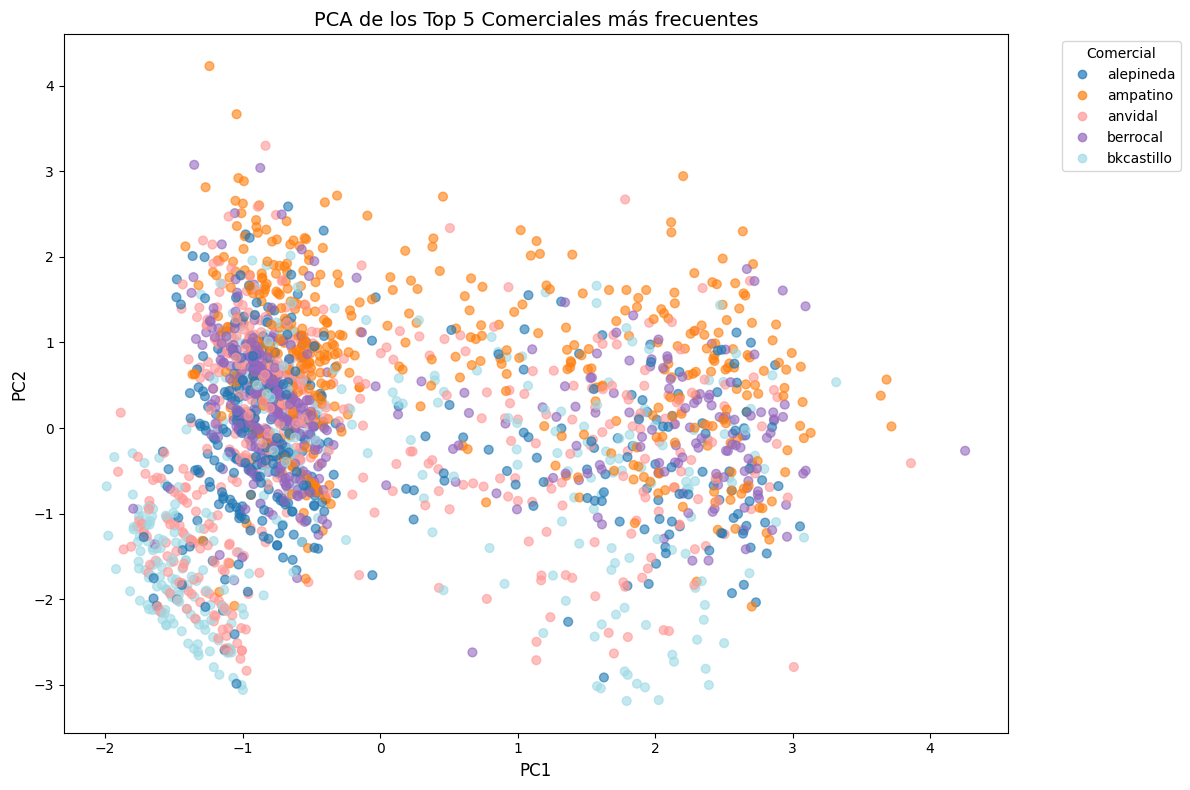

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

N = 5

top_comerciales = (
    df["COMERCIAL"]
    .value_counts()
    .head(N)
    .index
)

df_top = df[df["COMERCIAL"].isin(top_comerciales)].copy()

print(f"Comerciales incluidos ({N}):")
print(top_comerciales)

X = df_top[vars_dep]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df_top["PC1"] = components[:, 0]
df_top["PC2"] = components[:, 1]

# Colores por comercial
df_top["COMERCIAL_CODE"] = df_top["COMERCIAL"].astype("category").cat.codes

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df_top["PC1"],
    df_top["PC2"],
    c=df_top["COMERCIAL_CODE"],
    cmap="tab20",
    alpha=0.6,
    s=40
)

plt.title(f"PCA de los Top {N} Comerciales más frecuentes", fontsize=14)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)

# Agregar leyenda con nombres reales
handles, _ = scatter.legend_elements(prop="colors", alpha=0.7)
legend_labels = df_top["COMERCIAL"].astype("category").cat.categories

plt.legend(
    handles,
    legend_labels,
    title="Comercial",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=10
)

plt.tight_layout()
plt.show()


In [22]:
eigenvalues = pca.explained_variance_

print("\n=== Eigenvalues ===")
for i, val in enumerate(eigenvalues, start=1):
    print(f"PC{i}: {val:.4f}")

print("\n=== Varianza explicada (%) por componente ===")
for i, ratio in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i}: {ratio*100:.2f}%")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC1", f"PC2"],
    index=vars_dep
)

print("\n=== Eigenvectors / Loadings ===")
print(loadings.round(4))



=== Eigenvalues ===
PC1: 1.9522
PC2: 1.2977

=== Varianza explicada (%) por componente ===
PC1: 32.52%
PC2: 21.62%

=== Eigenvectors / Loadings ===
                      PC1     PC2
SCORE             -0.2473  0.3715
DIAS DE MORA _LOG  0.6669 -0.0544
SALDO VENCIDO_LOG  0.6668 -0.0876
CUOTAMENSUAL       0.0057  0.2479
TOTAL INGRESOS_YJ  0.1101  0.6812
TOTAL EGRESOS     -0.1931 -0.5708


In [19]:
import numpy as np
from scipy.spatial.distance import mahalanobis

# Matriz de covarianza inversa (para la distancia de Mahalanobis)
cov_matrix = np.cov(df[vars_dep].values.T)
cov_inv = np.linalg.inv(cov_matrix)

# Media global
global_mean = df[vars_dep].mean().values

distances = {}

# Calcular distancia por comercial
for com, sub in df.groupby("COMERCIAL"):
    mean_com = sub[vars_dep].mean().values
    d = mahalanobis(mean_com, global_mean, cov_inv)
    distances[com] = d

# Top comerciales más diferentes
ranking = sorted(distances.items(), key=lambda x: x[1], reverse=True)

print("=== Comerciales más diferentes al perfil global ===")
for com, dist in ranking[:10]:
    print(f"{com}: distancia = {dist:.3f}")


C:\Users\kirad\AppData\Local\Temp\ipykernel_25560\4028906642.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for com, sub in df.groupby("COMERCIAL"):


=== Comerciales más diferentes al perfil global ===
colte_ccjjairom: distancia = 5.481
colte_mcortesq: distancia = 5.188
colte_cgonzalezb: distancia = 4.619
dentix_emaldonadob: distancia = 4.532
colte_jsepulvedao: distancia = 3.655
colte_ccdsguevara: distancia = 3.560
colte_jsalazaro: distancia = 3.510
dentix_fmolinaf: distancia = 3.381
dentix_kmorenoc: distancia = 3.276
colte_vaboudjians: distancia = 3.145
